# Giai đoạn 9 — Tinh chỉnh siêu tham số

```
┌───────────────────────────────────────────────────────────────────────────────────────┐
│                                      09_TinhChinh                                     │
└───────────────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 07_TachTrainTest/train.csv   —  11.880 dòng
    • 07_TachTrainTest/val.csv     —  2.546 dòng
    • 08_MocChuan/moc_chuan.json   —  bốn mốc để so
         │
         ▼
  XỬ LÝ
    1. Quét lưới 48 cấu hình siêu tham số
    2. RÀNG BUỘC 1 — KHÁM PHÁ train Top-3 ≤ 95%   (vượt là nhớ vẹt, loại thẳng)
    3. RÀNG BUỘC 2 — KHÁM PHÁ chênh train−val ≤ 10 điểm
    4. Trong số cấu hình HỢP LỆ, chọn Top-3 khám phá trên val cao nhất
    5. Đối chứng tầng tư vấn (Top-2): mô hình chung che bớt  vs  mô hình riêng từng nhóm
    6. Kiểm lại: có hơn cả bốn mốc không
         │
         ▼
  ĐẦU RA
    • 09_TinhChinh/sieu_tham_so.json  —  Giai đoạn 10 đọc file này
    • 09_TinhChinh/ket_qua_quet.csv
    • 09_TinhChinh/hinh_9_*.png       —  2 hình
```

## Vấn đề cần chữa

Giai đoạn 8 cho thấy cấu hình mặc định **nhớ vẹt** — nhưng hai chế độ cho hai bức
tranh hoàn toàn khác nhau (số thật đọc từ `moc_chuan.json`, không viết tay).

Chế độ **tư vấn** trông lành vì đó là bài toán dễ: chọn 2 ngành trong một nhóm 3–7
ngành. Mốc 3 ở Giai đoạn 8 cho thấy chỉ dùng 15 cột one-hot tổ hợp, không Likert, không
điểm, đã đạt mức cao ở tầng này. Chế độ **khám phá** (xếp hạng cả 39 ngành) mới là bài
toán thật, và ở đó khoảng cách train−val lớn gấp nhiều lần.

XGBoost 400 cây độ sâu 5 trên 11.880 dòng thừa sức nhớ hết. Bản thân `train = 100%`
không bất thường với mô hình dung lượng lớn; vấn đề nằm ở **khoảng cách**.

## Hai ràng buộc CỨNG — đo trên chế độ KHÁM PHÁ

```python
KP_TRAIN_TOI_DA = 0.95   # khám phá train Top-3 vượt mức này → nhớ vẹt, LOẠI THẲNG
KP_GAP_TOI_DA   = 0.10   # khám phá chênh train − val vượt 10 điểm → LOẠI THẲNG
```

**Vì sao phải là khám phá, không phải tư vấn.** Lần chạy đầu áp lên tư vấn Top-3 và kết
quả là **0/48 cấu hình hợp lệ** — cấu hình nhẹ nhất trong lưới (150 cây, sâu 3) vẫn
cho tư vấn train 98,0%, vượt ngưỡng 95%. Ràng buộc loại sạch cả lưới, rồi một nhánh
dự phòng âm thầm chọn đại một cấu hình. Con số "chênh 1,9 điểm" ghi trong
`sieu_tham_so.json` trông đẹp nhưng nó không phải kết quả của việc chọn lọc nào cả.

Một ràng buộc mà 100% ứng viên vi phạm thì không phải ràng buộc — nó là lỗi đặt ngưỡng.

**Nhánh dự phòng đã bị gỡ.** Thay bằng `assert`: không cấu hình nào hợp lệ thì notebook
dừng hẳn, chứ không đi tiếp với một lựa chọn không có căn cứ.

Cấu hình nào vi phạm thì bị loại **bất kể Top-3 trên val đẹp tới đâu**. Chỉ chọn trong
số còn lại, và chọn theo **khám phá** — vì ràng buộc đặt ở đâu thì tiêu chí chọn phải
ở đó, nếu không thì hai thứ không ăn nhập gì với nhau.

Đánh đổi: Top-3 sẽ tụt vài điểm so với con số ở Giai đoạn 8. Nhưng con số còn lại mới là
con số dùng được — nó không dựa vào việc mô hình đã nhìn thấy dữ liệu huấn luyện.

> **Đừng siết `KP_GAP_TOI_DA` quá tay.** Ép xuống quá thấp sẽ làm mọi cấu hình rơi về
> đúng mức mốc đoán bừa — kết quả "đẹp" nhưng mô hình đã suy biến thành cái máy đoán
> ngành đông nhất.

## Đối chứng tầng tư vấn: mô hình chung, hay mô hình riêng từng nhóm?

Hệ thống có hai tầng, đúng cách web gọi API:

| Tầng | Gọi | Việc |
|---|---|---|
| **khám phá** | `diem(X)` | chưa biết gì → xếp hạng cả 39 ngành |
| **tư vấn** | `diem(X, nhom)` | người dùng đã chọn nhóm → xếp hạng ngành trong nhóm đó |

Tầng tư vấn hiện dùng **mô hình chung 39 lớp rồi che bỏ ngành ngoài nhóm**. Có một
cách khác: `rieng_nhom=True` — mỗi nhóm một mô hình nhỏ, chỉ học phân biệt 3–7 ngành
của nhóm đó thay vì trải sức phân biệt mọi cặp trong 39 ngành, kể cả những cặp ở hai
nhóm khác hẳn nhau mà thực tế không bao giờ phải so.

Không quét hết lưới cho cả hai — `rieng_nhom` chỉ ảnh hưởng tầng tư vấn, không đụng
tới khám phá, nên tiêu chí chọn cấu hình không đổi. Chốt siêu tham số bằng khám phá
trước, rồi so đúng **hai** lựa chọn ở tầng tư vấn, đo bằng **Top-2** — đúng số gợi ý
tầng này hiển thị. Rẻ hơn nhiều mà trả lời đúng câu hỏi.

## Hướng giảm dung lượng mô hình

| Tham số | Mặc định | Quét | Tác dụng |
|---|---:|---|---|
| `n_estimators` | 400 | 150 · 250 | ít cây hơn → ít nhớ hơn |
| `max_depth` | 5 | 3 · 4 · 5 | cây nông hơn → luật đơn giản hơn |
| `min_child_weight` | 3 | 3 · 10 | lá phải có đủ mẫu mới tách |
| `reg_lambda` | 5 | 5 · 20 | phạt trọng số lớn |
| `colsample_bytree` | 0.6 | 0.4 · 0.6 | mỗi cây thấy ít cột hơn |

## Chốt bằng tập val, không đụng test

`test_KHOA.csv` còn niêm phong. Mọi quyết định ở đây dựa trên `val.csv`.

Đây là lý do phải chia ba tập ngay từ đầu: nếu tinh chỉnh trên chính tập test thì con số
cuối cùng đã bị tập test tham gia vào quyết định thiết kế, và nó sẽ lạc quan hơn thực tế.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Điểm vận hành của sản phẩm: tầng tư vấn hiện K_TU_VAN gợi ý, tầng khám phá hiện
# K_KHAM_PHA. Nhóm nhỏ nhất có 3 ngành nên Top-3 tư vấn tự đúng 100% ở nhóm đó mà
# không cần mô hình — Top-2 là mức vẫn tách được mô hình khỏi mốc đoán bừa.
# Top-1/2/3/5 vẫn báo cáo đủ để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)
K_TU_VAN = 2
K_KHAM_PHA = 5

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_HocPhanPhoi",
    4: "04_SinhDacTrung",
    5: "05_KiemDinhDuLieuSinh",
    6: "06_NiemPhongKhaoSat",
    7: "07_TachTrainTest",
    8: "08_MocChuan",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def dat_nhan(ax, xs, ys, nhan, fs=9, mau=None):
    """Đặt nhãn cạnh từng điểm mà KHÔNG đè lên nhau.

    Viết thẳng chữ lên chấm thì các điểm sát nhau (cùng 0%, cùng cỡ dữ liệu) chồng
    chữ thành một mảng không đọc được. Hàm thử lần lượt các vị trí quanh điểm, lấy
    vị trí đầu tiên không chạm nhãn đã đặt; nhãn phải dời xa có đường dẫn về điểm.
    """
    from matplotlib.text import Text

    fig = ax.figure
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    vi_tri = [(5, 3), (5, -11), (-5, 3), (-5, -11)]
    for tang in range(1, 8):
        vi_tri += [(9, 3 + 11 * tang), (9, -11 - 11 * tang),
                   (-9, 3 + 11 * tang), (-9, -11 - 11 * tang)]
    da_dat = []

    def thu(x, y, t, dx, dy):
        a = ax.annotate(t, (x, y), xytext=(dx, dy), textcoords="offset points",
                        fontsize=fs, fontweight="bold", color=mau or C_DAM, zorder=6,
                        ha="left" if dx > 0 else "right", va="bottom",
                        arrowprops=(dict(arrowstyle="-", color="#8A949E", lw=.6,
                                         shrinkA=0, shrinkB=2) if abs(dy) > 12 else None))
        a.update_positions(r)
        return a, Text.get_window_extent(a, r)

    for x, y, t in zip(xs, ys, nhan):
        for dx, dy in vi_tri:
            a, hop = thu(x, y, t, dx, dy)
            if not any(hop.overlaps(h) for h in da_dat):
                break
            a.remove()
        else:
            a, hop = thu(x, y, t, *vi_tri[0])      # hết chỗ — đặt vị trí đầu
        da_dat.append(hop)


def hinh_theo_nganh(rd, cot, nhan_y, co_cham, sao=None, ghi_chu_sao=""):
    """Mỗi chấm một ngành: ngang là số dòng huấn luyện (log), dọc là độ chính xác.

    Ngành đáng chú ý (dưới 50% hoặc dưới 120 dòng) chỉ ghi SỐ cạnh chấm; tên đầy đủ
    nằm ở bảng bên phải. Không cắt cụt tên ngành, không để chữ đè lên nhau.
    """
    chu_y = (rd[(rd[cot] < .5) | (rd.n_hoc < 120)]
             .sort_values([cot, "n_hoc"]).head(22).reset_index(drop=True))
    cmap = plt.get_cmap("RdYlGn")
    fig = plt.figure(figsize=(16, 6.6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1], wspace=0.08)
    ax, al = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    sc = ax.scatter(rd.n_hoc, rd[cot] * 100, s=14 + rd.n_test * 1.6, c=rd[cot] * 100,
                    cmap=cmap, vmin=0, vmax=100, edgecolor="white", lw=.8, zorder=3)
    ax.set_xscale("log")
    ax.set_ylim(-10, 110)
    ax.set_xlabel("Số dòng huấn luyện của ngành (thang log)")
    ax.set_ylabel(nhan_y)
    fig.colorbar(sc, ax=ax, pad=0.012, fraction=0.035).set_label(nhan_y)
    dat_nhan(ax, chu_y.n_hoc.values, chu_y[cot].values * 100,
             [str(i + 1) for i in range(len(chu_y))])

    al.axis("off")
    al.set_xlim(0, 1)
    al.set_ylim(0, 1)
    al.text(0, 1.0, "Ngành được đánh số", fontsize=12, fontweight="bold", va="bottom")
    al.text(1, 1.0, "dòng huấn luyện · độ chính xác", fontsize=9, color="#5A6672",
            ha="right", va="bottom")
    buoc = min(0.93 / max(len(chu_y), 1), 0.07)
    for i, r in chu_y.iterrows():
        y = 0.96 - i * buoc
        al.scatter([0.012], [y - buoc * 0.32], s=46, color=cmap(r[cot]),
                   edgecolor="#8A949E", lw=.5, clip_on=False)
        al.text(0.075, y, str(i + 1), fontsize=10, fontweight="bold", ha="right", va="top")
        ten = r.ten + (" *" if sao and r[sao] else "")
        al.text(0.095, y, ten, fontsize=10, va="top")
        al.text(1, y, f"{int(r.n_hoc):,}".replace(",", ".") + f" · {r[cot] * 100:.0f}%",
                fontsize=9.5, ha="right", va="top", color="#5A6672")
    chu = f"Cỡ chấm: {co_cham}."
    if sao:
        chu += f"   * {ghi_chu_sao}."
    al.text(0, 0.96 - len(chu_y) * buoc - 0.02, chu, fontsize=9, color="#5A6672", va="top")
    return fig, ax, al


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True, co_fold=False):
    """Đọc mọi thứ notebook huấn luyện cần.

    ⚠️ HƯỚNG 2 — khác Hướng 1 ở chỗ căn bản: 676 phiếu khảo sát KHÔNG bao giờ
    vào tập huấn luyện. Giai đoạn 6 niêm phong toàn bộ chúng làm tập kiểm định
    người thật độc lập; chia train/val/test chỉ diễn ra trên phần TTTH.

        Giai đoạn 3–5   d["train"] = TOÀN BỘ 676 phiếu — chỉ để BỘ SINH học
                                     phân phối, không phải để XGBoost học
        Giai đoạn 8–9   co_fold=True  → đọc train.csv và cv_folds.json của GĐ 7
        Giai đoạn 10    co_test=True  → mở CẢ HAI tập kiểm định ĐÚNG MỘT LẦN:
                                     test TTTH và 676 phiếu khảo sát niêm phong

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json — nguồn chuẩn duy nhất.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(1) / "khaosat_sach.csv"),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_fold:
        d["train"] = pd.read_csv(thu_muc(7) / "train.csv")
        d["folds"] = json.loads((thu_muc(7) / "cv_folds.json").read_text(encoding="utf-8"))
    if co_test:
        d["test"] = pd.read_csv(thu_muc(7) / "test_KHOA.csv")
        # Tập kiểm định NGƯỜI THẬT — niêm phong từ Giai đoạn 6, mở cùng lúc.
        d["khaosat_niemphong"] = pd.read_csv(thu_muc(6) / "khaosat_NIEMPHONG.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

from xgboost import XGBClassifier


def mo_hinh(**kw):
    """XGBoost phân loại. KHÔNG ép `objective` — với nhóm 2 ngành XGBoost tự
    dùng binary:logistic (không có num_class), ép multi:softprob sẽ lỗi."""
    return XGBClassifier(**{**dict(
        max_depth=5, n_estimators=400, learning_rate=0.06, min_child_weight=3,
        subsample=0.8, colsample_bytree=0.6, reg_lambda=5.0,
        tree_method="hist", n_jobs=-1, verbosity=0, random_state=SEED), **kw})


class MoHinhNganh:
    """Mô hình gợi ý ngành. Chỉ dùng XGBoost phân loại — không có gì khác.

    Cách hoạt động, một câu:
        mô hình cho ra XÁC SUẤT cho từng ngành → bỏ những ngành không thuộc
        nhóm người dùng chọn → lấy k ngành xác suất cao nhất còn lại.

    Hai chế độ, đúng cách web gọi API:
        fieldId = None  → xếp hạng cả 39 ngành          (chế độ khám phá)
        fieldId = k     → chỉ xếp hạng ngành trong nhóm k (chế độ tư vấn)

    `rieng_nhom=True` → mỗi nhóm một mô hình nhỏ, chỉ học các ngành của nhóm đó.
    Mô hình chung phải trải sức phân biệt mọi cặp ngành, kể cả cặp ở hai nhóm
    khác hẳn nhau mà thực tế không bao giờ phải so; mô hình riêng chỉ học đúng
    việc phân biệt vài ngành trong một nhóm.
    """

    def __init__(self, D, hp=None, rieng_nhom=False, hp_nhom=None,
                 phan_tang=None):
        """`phan_tang` — dict {mã nhóm: {mã ngành: id lĩnh vực con}}.

        Với nhóm nhiều ngành, học MỘT LƯỢT 10 lớp bắt mô hình vẽ đồng thời 45
        đường ranh giới, kể cả những cặp gần như không tách được. Học hai bước
        thì bước 1 chỉ phải tách vài lĩnh vực con — việc dễ hơn và có tín hiệu
        thật — rồi bước 2 mới đi vào chỗ khó:

            P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)

        Mô hình TỰ đoán lĩnh vực con, người dùng không cung cấp gì thêm, nên mốc
        đoán bừa không đổi. Đo trên khối Kinh doanh (10 ngành): 44.5% → 49.3%.
        """
        self.D = D
        self.hp = hp or {}
        self.rieng_nhom = rieng_nhom
        self.hp_nhom = hp_nhom or {}
        self.phan_tang = phan_tang or {}
        self.trong = {g: [n for n in D["nganh"] if D["nhom"][n] == g]
                      for g in sorted(set(D["nhom"].values()))}

    @staticmethod
    def _fit1(X, y, hp, w=None):
        """XGBoost 3.x bắt buộc mã lớp liền mạch 0..n-1, mà lô nhỏ có thể vắng
        vài ngành — nên phải đánh số lại rồi ánh xạ ngược lúc dự đoán."""
        co = np.unique(y)
        m = mo_hinh(**hp).fit(X, np.searchsorted(co, y), sample_weight=w)
        return m, co

    def fit(self, X, y, w=None):
        X, y = np.asarray(X), np.asarray(y)
        self.m, self.co = self._fit1(X, y, self.hp, w)
        self.m_tang = {}
        if self.rieng_nhom:
            self.m_nhom = {}
            for g, ds in self.trong.items():
                sel = np.isin(y, ds)
                if len(ds) < 2 or sel.sum() < 5 or len(np.unique(y[sel])) < 2:
                    continue
                hp_g = self.hp_nhom.get(g, self.hp)
                w_g = None if w is None else w[sel]
                self.m_nhom[g] = self._fit1(X[sel], y[sel], hp_g, w_g)
                if g in self.phan_tang:
                    self.m_tang[g] = self._fit_tang(
                        X[sel], y[sel], w_g, self.phan_tang[g], hp_g)
        return self

    def _fit_tang(self, X, y, w, ban_do, hp):
        """Hai bước: đoán lĩnh vực con trước, rồi đoán ngành trong lĩnh vực đó."""
        s = np.array([ban_do[v] for v in y])
        co_s = np.unique(s)
        if len(co_s) < 2:
            return None
        m_sub = mo_hinh(**hp).fit(X, np.searchsorted(co_s, s), sample_weight=w)
        con = {}
        for k, sv in enumerate(co_s):
            m_ = s == sv
            if len(np.unique(y[m_])) < 2:
                con[k] = (None, np.unique(y[m_]))
                continue
            con[k] = self._fit1(X[m_], y[m_], hp, None if w is None else w[m_])
        return m_sub, co_s, con

    def _rai(self, pr, co, n_dong):
        """Trải xác suất của model (chỉ vài lớp) ra đủ 39 cột ngành."""
        S = np.zeros((n_dong, len(self.D["nganh"])))
        for c, ma in enumerate(co):
            S[:, self.D["i_nganh"][ma]] = pr[:, c]
        return S

    def _diem_tang(self, X, bo):
        """P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)."""
        m_sub, co_s, con = bo
        p_sub = m_sub.predict_proba(X)
        S = np.zeros((len(X), len(self.D["nganh"])))
        for k in range(len(co_s)):
            m, co = con[k]
            if m is None:
                for ma in co:
                    S[:, self.D["i_nganh"][ma]] = p_sub[:, k]
                continue
            pr = m.predict_proba(X)
            for c, ma in enumerate(co):
                S[:, self.D["i_nganh"][ma]] = p_sub[:, k] * pr[:, c]
        return S

    def diem(self, X, nhom_biet=None):
        """Xác suất trên 39 ngành. `nhom_biet` = mã nhóm người dùng chọn."""
        X = np.asarray(X)
        S = self._rai(self.m.predict_proba(X), self.co, len(X))
        if nhom_biet is None:
            return S
        nhom_biet = np.asarray(nhom_biet)
        if self.rieng_nhom:
            for g, (m, co) in self.m_nhom.items():
                sel = nhom_biet == g
                if not sel.any():
                    continue
                if self.m_tang.get(g) is not None:
                    S[sel] = self._diem_tang(X[sel], self.m_tang[g])
                else:
                    S[sel] = self._rai(m.predict_proba(X[sel]), co, int(sel.sum()))
        # Bỏ mọi ngành ngoài nhóm người dùng đã chọn
        mat_na = np.zeros_like(S)
        for i, g in enumerate(nhom_biet):
            for n in self.trong[int(g)]:
                mat_na[i, self.D["i_nganh"][n]] = 1.0
        return S * mat_na


def top_k(S, y, NG, ks=TOP_K):
    o = np.argsort(-S, axis=1)
    return {k: float(np.mean([y[i] in NG[o[i, :k]] for i in range(len(y))])) for k in ks}


def bua_toan_bo(n_lop, ks=TOP_K):
    """Đoán bừa k ngành trong toàn bộ danh mục."""
    return {k: min(k, n_lop) / n_lop for k in ks}


def bua_trong_nhom(y, nhom, ks=TOP_K):
    """Đoán bừa k ngành TRONG nhóm đúng.

    Bắt buộc báo cáo kèm: nhóm chỉ có 2 ngành thì Top-3 tự đúng 100% mà không cần
    mô hình nào. Thiếu cột này, một con số 85% có thể chỉ hơn đoán bừa vài điểm mà
    người đọc vẫn tưởng mô hình giỏi.
    """
    co = pd.Series(list(nhom.values())).value_counts()
    return {k: float(np.mean([min(k, co[nhom[m]]) / co[nhom[m]] for m in y])) for k in ks}


def ky_nang(acc, bua):
    """Phần lỗi của đoán bừa mà mô hình XOÁ ĐƯỢC.

        kỹ năng = (acc − bừa) / (1 − bừa)

    Vì sao cần chỉ số này: chia nhóm càng nhỏ thì đoán bừa càng cao, nên con số
    độ chính xác trần trụi KHÔNG so được giữa các cách chia nhóm khác nhau.
    Kỹ năng đã trừ sạch lợi thế đó — 0% là chỉ ngang đoán bừa, 100% là hoàn hảo.

    Ví dụ: 7 khối đạt 69.7% với bừa 49.2% → kỹ năng 40.3%.
           10 nhóm đạt 87.8% với bừa 75.9% → kỹ năng 49.3%.
    Con số thứ hai cao hơn thật, nhưng không cao như 87.8% so với 69.7% gợi ý.
    """
    return (acc - bua) / (1 - bua) if bua < 1 else float("nan")


def bua_pho_bien(y_hoc, y_do, nhom, ks=TOP_K):
    """Mốc đối chứng THỰC TẾ: luôn gợi ý k ngành ĐÔNG SINH VIÊN NHẤT trong nhóm.

    Đây là quy tắc mà bất kỳ ai cũng làm được bằng vài dòng code, KHÔNG cần khảo
    sát, KHÔNG cần điểm thi, KHÔNG cần mô hình. Tần suất học từ `y_hoc` (tập
    train), rồi áp lên `y_do`.

    VÌ SAO CẦN: mốc "đoán bừa" (chọn ngẫu nhiên trong nhóm) quá dễ vượt và không
    ai xây hệ thống như vậy. Phân bố ngành trong nhóm thường lệch mạnh, nên chỉ
    riêng việc gợi ý ngành phổ biến đã đúng khá nhiều. Một mô hình học máy chỉ
    thực sự có giá trị khi vượt được mốc NÀY.
    """
    y_hoc, y_do = np.asarray(y_hoc), np.asarray(y_do)
    g_hoc = np.array([nhom[m] for m in y_hoc])
    g_do = np.array([nhom[m] for m in y_do])
    out = {}
    for k in ks:
        top = {g: set(pd.Series(y_hoc[g_hoc == g]).value_counts().head(k).index)
               for g in np.unique(g_hoc)}
        out[k] = float(np.mean([y_do[i] in top.get(g_do[i], set())
                                for i in range(len(y_do))]))
    return out


def ky_nang_vs(acc, moc):
    """Phần lỗi của MỘT MỐC BẤT KỲ mà mô hình xoá được."""
    return (acc - moc) / (1 - moc) if moc < 1 else float("nan")


def chi_so_lop(S, y, NG, co_auc=True):
    """Các chỉ số phân loại chuẩn, bổ sung cho Top-k.

    Vì sao cần: độ chính xác trên 39 ngành mất cân bằng bị ngành đông chi phối.
    Mốc "luôn đoán ngành đông nhất trong nhóm" đã đạt 88,5% ở chế độ tư vấn mà
    không dùng mô hình nào. **macro-F1** cho mỗi ngành trọng số bằng nhau nên nó
    phơi ra chuyện mô hình bỏ rơi ngành ít hồ sơ; **weighted-F1** giữ trọng số
    theo cỡ ngành, luôn cao hơn — chênh lệch giữa hai con số chính là mức độ
    thiên vị ngành đông.

    ⚠️ `auc_ovr` ở đây là AUC ĐÁNH GIÁ PHÂN LOẠI (một-đối-phần-còn-lại, càng
    gần 1 càng tốt). KHÔNG phải AUC ở Giai đoạn 5 — con số đó đo bộ phân biệt
    thật/giả và **0,50 mới là lý tưởng**. Hai chỉ số trùng tên, ngược chiều
    nhau; báo cáo phải gọi rõ tên từng cái.

    Chỉ tính AUC khi `S` là phân phối xác suất đầy đủ trên 39 ngành. Ở chế độ
    tư vấn, `S` đã bị che bớt ngành ngoài nhóm nên hàng không còn tổng bằng 1 —
    truyền `co_auc=False`.
    """
    from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

    y = np.asarray(y)
    du = np.asarray(NG)[np.argmax(S, axis=1)]          # dự đoán Top-1
    ra = {
        "acc_top1": float(np.mean(du == y)),
        "f1_macro": float(f1_score(y, du, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y, du, average="weighted", zero_division=0)),
        "precision_macro": float(precision_score(y, du, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y, du, average="macro", zero_division=0)),
        "auc_ovr": float("nan"),
    }
    if co_auc:
        # roc_auc_score đòi mọi lớp trong `labels` phải xuất hiện ở y_true; ngành
        # vắng mặt trong lát cắt đang đo thì bỏ khỏi phép tính chứ không bỏ cả AUC.
        co = np.isin(np.asarray(NG), np.unique(y))
        if co.sum() >= 2:
            P = S[:, co]
            t = P.sum(axis=1, keepdims=True)
            P = np.divide(P, t, out=np.full_like(P, 1 / co.sum()), where=t > 0)
            try:
                ra["auc_ovr"] = float(roc_auc_score(
                    y, P, multi_class="ovr", average="macro",
                    labels=np.asarray(NG)[co]))
            except ValueError:
                pass
    return ra


def hang_cua_nganh_dung(S, y, NG):
    """Thứ hạng (đếm từ 1) của ngành đúng trong danh sách mô hình xếp ra."""
    o = np.argsort(-np.asarray(S), axis=1)
    NG = np.asarray(NG)
    y = np.asarray(y)
    return np.array([int(np.where(NG[o[i]] == y[i])[0][0]) + 1 for i in range(len(y))])


def chi_so_xep_hang(S, y, NG, k):
    """Chỉ số đánh giá đúng cho hệ thống trả về k gợi ý.

    Vì sao không dùng F1/precision/recall: chúng giả định hệ thống trả về MỘT
    nhãn. Hệ thống này trả 2 gợi ý ở chế độ tư vấn và 5 ở chế độ khám phá, nên
    nhóm chỉ số Top-1 đo tại một điểm vận hành không tồn tại trong sản phẩm.

    ⚠️ KHÔNG báo cáo precision@k và recall@k. Mỗi em chỉ có ĐÚNG MỘT ngành đúng,
    nên:
        recall@k    = hit@k        (trùng khít, không phải chỉ số mới)
        precision@k = hit@k / k    (chia cứng cho k, không mang thêm thông tin)
    Đưa vào bảng chỉ làm con số trông tệ đi mà không nói thêm được gì.

    Các chỉ số trả về:
        hit_k        — tỉ lệ ngành đúng nằm trong k gợi ý. Chính là Top-k.
        macro_hit_k  — trung bình hit@k TỪNG NGÀNH rồi mới lấy trung bình. Đây là
                       bản Top-k của macro-F1: mỗi ngành trọng số bằng nhau, nên
                       nó phơi ra chuyện mô hình bỏ rơi ngành ít hồ sơ, nhưng hỏi
                       tại ĐÚNG điểm vận hành thay vì hỏi ở Top-1.
        mrr          — trung bình 1/thứ hạng. Giữ được thông tin về THỨ TỰ mà
                       hit@k làm mờ đi: xếp đúng ở hạng 1 khác hẳn hạng 3.
        ndcg_k       — chấm theo vị trí, cắt ở k. Hạng 1 trọn điểm, hạng 2 được
                       1/log₂3 ≈ 0,63, ra ngoài k thì 0. Đây là chỉ số tương ứng
                       khi cần "AUC có cắt ở k" — AUC thật không có ngưỡng cắt
                       nên không tồn tại khái niệm AUC@k.
    """
    r = hang_cua_nganh_dung(S, y, NG)
    trung = r <= k
    per = pd.DataFrame({"y": np.asarray(y), "t": trung}).groupby("y").t.mean()
    return {
        "k": int(k),
        "hit_k": float(trung.mean()),
        "macro_hit_k": float(per.mean()),
        "mrr": float(np.mean(1.0 / r)),
        "ndcg_k": float(np.mean(np.where(trung, 1.0 / np.log2(r + 1), 0.0))),
        "hang_trung_vi": float(np.median(r)),
        "hang_trung_binh": float(r.mean()),
        "n_nganh_duoi_50": int((per < 0.5).sum()),
        "n_nganh": int(len(per)),
    }


def mrr_doan_bua(y, nhom=None, n_lop=None):
    """MRR của việc bốc ngẫu nhiên — mốc để so với MRR của mô hình.

    Bốc ngẫu nhiên trong m lựa chọn thì kỳ vọng 1/hạng là trung bình điều hoà
    (1/1 + 1/2 + … + 1/m) / m. Truyền `nhom` cho chế độ tư vấn (m = cỡ nhóm),
    `n_lop` cho chế độ khám phá (m = 39).
    """
    if n_lop is not None:
        return float(np.mean(1.0 / np.arange(1, n_lop + 1)))
    co = pd.Series(list(nhom.values())).value_counts()
    return float(np.mean([np.mean(1.0 / np.arange(1, co[nhom[m]] + 1)) for m in y]))


def in_chi_so_xep_hang(hang):
    """`hang` = [(tên tầng, dict từ chi_so_xep_hang, mrr đoán bừa), …]"""
    print("═" * 104)
    print(f"{'Tầng':<24}{'k':>4}{'Hit@k':>10}{'macro Hit@k':>14}{'MRR':>9}"
          f"{'MRR bừa':>10}{'NDCG@k':>10}{'hạng t.vị':>11}{'ngành <50%':>12}")
    print("─" * 104)
    for ten, d, mb in hang:
        print(f"{ten:<24}{d['k']:>4}{d['hit_k']:>9.1%}{d['macro_hit_k']:>14.1%}"
              f"{d['mrr']:>9.3f}{mb:>10.3f}{d['ndcg_k']:>10.3f}"
              f"{d['hang_trung_vi']:>11.0f}"
              f"{str(d['n_nganh_duoi_50'])+'/'+str(d['n_nganh']):>12}")
    print("═" * 104)
    print("Hit@k = Top-k · macro Hit@k = bản Top-k của macro-F1 (mỗi ngành ngang nhau)")
    print("MRR giữ thông tin THỨ TỰ mà Hit@k làm mờ · NDCG@k chấm theo vị trí, cắt ở k")
    print("KHÔNG báo cáo precision@k (= hit@k/k) và recall@k (= hit@k) — trùng lặp")


def in_chi_so_lop(hang):
    """In bảng F1 / AUC. `hang` = [(tên lát cắt, dict từ chi_so_lop, n), …]"""
    print("═" * 100)
    print(f"{'Lát cắt':<30}{'n':>8}{'Top-1':>9}{'F1 macro':>11}{'F1 w.':>9}"
          f"{'P macro':>10}{'R macro':>10}{'AUC OvR':>10}")
    print("─" * 100)
    for ten, d, n in hang:
        a = "—" if np.isnan(d["auc_ovr"]) else f"{d['auc_ovr']:.3f}"
        print(f"{ten:<30}{n:>8,}{d['acc_top1']:>9.1%}{d['f1_macro']:>11.3f}"
              f"{d['f1_weighted']:>9.3f}{d['precision_macro']:>10.3f}"
              f"{d['recall_macro']:>10.3f}{a:>10}")
    print("═" * 100)
    print("macro = mỗi ngành trọng số bằng nhau · weighted = theo cỡ ngành")
    print("chênh macro↔weighted càng lớn, mô hình càng thiên vị ngành đông")
    print("AUC OvR: càng gần 1 càng tốt — KHÁC AUC Giai đoạn 5 (0,50 là lý tưởng)")


def dong(ten, do_duoc, mocbua, ks=TOP_K):
    r = {"cau_hinh": ten}
    for k in ks:
        r[f"top{k}"], r[f"bua{k}"] = do_duoc[k], mocbua[k]
        r[f"hon{k}"] = do_duoc[k] - mocbua[k]
        r[f"kn{k}"] = ky_nang(do_duoc[k], mocbua[k])
    return r


def in_bang(rows, tieu_de="", ks=TOP_K):
    w = max([len(r["cau_hinh"]) for r in rows] + [20]) + 2
    tong = w + 35 * len(ks)
    if tieu_de:
        print("═" * tong); print(tieu_de)
    print("═" * tong)
    print(f"{'Cấu hình':{w}s}" + "".join(
        f"{'Top-'+str(k):>10s}{'bừa':>8s}{'hơn':>8s}{'kỹ năng':>9s}" for k in ks))
    print("─" * tong)
    for r in rows:
        # `hon` là hiệu hai tỉ lệ (0..1) → phải ×100 mới ra "điểm phần trăm";
        # in thẳng sẽ thành +0.4đ trong khi thực tế là +42.0đ.
        print(f"{r['cau_hinh']:{w}s}" + "".join(
            f"{r[f'top{k}']:9.1%} {r[f'bua{k}']:7.1%} {r[f'hon{k}']*100:+7.1f}đ"
            f"{r[f'kn{k}']:>9.1%}" for k in ks))
    print("═" * tong)
    print("kỹ năng = phần lỗi của đoán bừa mà mô hình xoá được — so được giữa"
          " các cách chia nhóm")


def bang_train_test(cap, ks=TOP_K):
    """Bảng TRAIN | TEST | chênh | đoán bừa | hơn bừa.

    `cap` = [(tên chế độ, chỉ số train, chỉ số test, mốc đoán bừa), …]
    Thầy yêu cầu báo cáo cả hai; khoảng cách lớn là dấu hiệu mô hình nhớ vẹt.
    """
    print("╔" + "═" * 74 + "╗")
    print("║" + " ĐỘ CHÍNH XÁC TRÊN TRAIN VÀ TEST ".center(74) + "║")
    print("╠" + "═" * 74 + "╣")
    print("║ " + f"{'':21s}{'TRAIN':>9s}{'TEST':>9s}{'chênh':>10s}"
          f"{'đoán bừa':>11s}{'hơn bừa':>11s}".ljust(73) + "║")
    for ten, tr, te, b in cap:
        print("╠" + "═" * 74 + "╣")
        print("║ " + ten.ljust(73) + "║")
        for k in ks:
            print("║ " + f"   Top-{k}{'':14s}{tr[k]:8.1%}{te[k]:9.1%}"
                  f"{(tr[k]-te[k])*100:+9.1f}đ{b[k]:10.1%}"
                  f"{(te[k]-b[k])*100:+10.1f}đ".ljust(73) + "║")
    print("╚" + "═" * 74 + "╝")

from itertools import product

OUT = thu_muc(9)
# Cả hai ràng buộc đo trên chế độ KHÁM PHÁ. Lần chạy đầu áp lên tư vấn Top-3 thì
# cấu hình nhẹ nhất của lưới cũng vượt ngưỡng — loại sạch 48/48.
KP_TRAIN_TOI_DA = 0.95    # RÀNG BUỘC CỨNG 1
KP_GAP_TOI_DA = 0.10      # RÀNG BUỘC CỨNG 2

LUOI = {
    "n_estimators": [150, 250],
    "max_depth": [3, 4, 5],
    "min_child_weight": [3, 10],
    "reg_lambda": [5.0, 20.0],
    "colsample_bytree": [0.4, 0.6],
}

D = nap(co_ttth=False)
train = pd.read_csv(thu_muc(7) / "train.csv")
val = pd.read_csv(thu_muc(7) / "val.csv")
MOC = json.loads((thu_muc(8) / "moc_chuan.json").read_text(encoding="utf-8"))
QL = ["ma_nganh", "ma_nhom", "nguon", "rui_ro_vong_tron", "sample_weight"]
COT = [c for c in train.columns if c not in QL]

Xtr, ytr, gtr = train[COT].values, train.ma_nganh.values, train.ma_nhom.values
Xva, yva, gva = val[COT].values, val.ma_nganh.values, val.ma_nhom.values

assert set(train.sample_weight.unique()) == {1.0}, "trọng số phải bằng nhau"

cau_hinh = [dict(zip(LUOI, v)) for v in product(*LUOI.values())]
print(f"Lưới      : {len(cau_hinh)} cấu hình")
for k, v in LUOI.items():
    print(f"   {k:<20} {v}")
print(f"\nRàng buộc (đo trên chế độ KHÁM PHÁ):")
print(f"   khám phá train Top-3      ≤ {KP_TRAIN_TOI_DA:.0%}")
print(f"   khám phá chênh train−val  ≤ {KP_GAP_TOI_DA:.0%}")

g8 = MOC["moc"]["MÔ HÌNH đủ dữ liệu"]
print(f"\nGiai đoạn 8 — mô hình chưa tinh chỉnh:")
print(f"   {'':12}{'train':>9}{'val':>9}{'chênh':>9}")
print(f"   {'tư vấn':<12}{g8['tv_train']:>9.1%}{g8['tv_val']:>9.1%}"
      f"{(g8['tv_train']-g8['tv_val'])*100:>+8.1f}đ")
print(f"   {'khám phá':<12}{g8['kp_train']:>9.1%}{g8['kp_val']:>9.1%}"
      f"{(g8['kp_train']-g8['kp_val'])*100:>+8.1f}đ  ← ràng buộc áp ở đây")

print(f"\nMốc cần vượt (khám phá Top-3):")
for t, v in MOC["moc"].items():
    if v["kp_val"] is not None:
        print(f"   {t:<34} {v['kp_val']:.1%}")

Lưới      : 48 cấu hình
   n_estimators         [150, 250]
   max_depth            [3, 4, 5]
   min_child_weight     [3, 10]
   reg_lambda           [5.0, 20.0]
   colsample_bytree     [0.4, 0.6]

Ràng buộc (đo trên chế độ KHÁM PHÁ):
   khám phá train Top-3      ≤ 95%
   khám phá chênh train−val  ≤ 10%

Giai đoạn 8 — mô hình chưa tinh chỉnh:
                   train      val    chênh
   tư vấn          99.9%    90.5%    +9.5đ
   khám phá        99.2%    75.8%   +23.4đ  ← ràng buộc áp ở đây

Mốc cần vượt (khám phá Top-3):
   1 · ngành đông nhất                23.0%
   2 · bừa trong nhóm                 7.7%
   3 · chỉ 15 cột tổ hợp              31.2%
   4 · bỏ 5 ngành vòng tròn (10.987 dòng) 70.7%
   MÔ HÌNH đủ dữ liệu                 75.8%


## 1. Quét lưới

In [2]:
def thu(hp):
    mh = MoHinhNganh(D, hp=hp).fit(Xtr, ytr)
    kp_tr = top_k(mh.diem(Xtr), ytr, D["nganh"])[3]
    kp_va = top_k(mh.diem(Xva), yva, D["nganh"])[3]
    tv_tr = top_k(mh.diem(Xtr, gtr), ytr, D["nganh"])[K_TU_VAN]
    tv_va = top_k(mh.diem(Xva, gva), yva, D["nganh"])[K_TU_VAN]
    return {**hp,
            "kp_train": kp_tr, "kp_val": kp_va, "gap_kp": kp_tr - kp_va,
            "tv_train": tv_tr, "tv_val": tv_va, "gap_tv": tv_tr - tv_va}


t0 = time.time()
ra = []
for i, hp in enumerate(cau_hinh, 1):
    ra.append(thu(hp))
    if i % 4 == 0 or i == len(cau_hinh):
        print(f"   {i}/{len(cau_hinh)}  [{time.time()-t0:.0f}s]", flush=True)
q = pd.DataFrame(ra)
q["hop_le"] = (q.kp_train <= KP_TRAIN_TOI_DA) & (q.gap_kp <= KP_GAP_TOI_DA)
q.to_csv(OUT / "ket_qua_quet.csv", index=False)

print(f"\nQuét xong {len(q)} cấu hình trong {time.time()-t0:.0f}s")
print(f"   hợp lệ : {int(q.hop_le.sum())}/{len(q)}")
print(f"   bị loại: {int((~q.hop_le).sum())}"
      f"  (khám phá train > {KP_TRAIN_TOI_DA:.0%} hoặc chênh > {KP_GAP_TOI_DA:.0%})")

# Đối chứng: cùng bộ ràng buộc này nếu áp lên TƯ VẤN thì còn lại bao nhiêu?
n_tv = int(((q.tv_train <= KP_TRAIN_TOI_DA) & (q.gap_tv <= KP_GAP_TOI_DA)).sum())
print(f"\n   Cùng ngưỡng đó áp lên chỉ số TƯ VẤN Top-{K_TU_VAN}: {n_tv}/{len(q)} hợp lệ"
      f"   (tư vấn train thấp nhất trong lưới = {q.tv_train.min():.1%})")
if n_tv == 0:
    print(f"   → Ngưỡng 95% vô nghĩa với chỉ số tư vấn vì bài toán đó quá dễ;")
    print(f"     mọi cấu hình đều vượt.")
print(f"   Chênh train−val tư vấn trải từ {q.gap_tv.min():.1%} tới {q.gap_tv.max():.1%},"
      f" khám phá từ {q.gap_kp.min():.1%} tới {q.gap_kp.max():.1%}.")

   4/48  [22s]


   8/48  [43s]


   12/48  [69s]


   16/48  [95s]


   20/48  [128s]


...

   36/48  [286s]


   40/48  [335s]


   44/48  [397s]


   48/48  [453s]



Quét xong 48 cấu hình trong 453s
   hợp lệ : 4/48
   bị loại: 44  (khám phá train > 95% hoặc chênh > 10%)

   Cùng ngưỡng đó áp lên chỉ số TƯ VẤN Top-2: 13/48 hợp lệ   (tư vấn train thấp nhất trong lưới = 92.3%)
   Chênh train−val tư vấn trải từ 4.5% tới 8.9%, khám phá từ 8.7% tới 21.8%.


In [3]:
hl = q[q.hop_le]

# KHÔNG có nhánh dự phòng. Lần chạy trước loại sạch 48/48 rồi âm thầm "tạm lấy
# cấu hình chênh nhỏ nhất" — pipeline chạy trót lọt và cho ra một cấu hình không
# có căn cứ nào. Thà dừng hẳn còn hơn.
assert len(hl) > 0, (
    f"KHÔNG cấu hình nào trong {len(q)} vượt được ràng buộc "
    f"(khám phá train ≤ {KP_TRAIN_TOI_DA:.0%}, chênh ≤ {KP_GAP_TOI_DA:.0%}).\n"
    f"Thấp nhất trong lưới: train {q.kp_train.min():.1%}, chênh {q.gap_kp.min():.1%}.\n"
    f"Phải nới ngưỡng hoặc thêm cấu hình nhẹ hơn vào LUOI — không được đi tiếp.")

# Ràng buộc đặt ở chỉ số khám phá thì tiêu chí chọn cũng phải ở đó.
chot = hl.loc[hl.kp_val.idxmax()]

print("=" * 108)
print(f"{'#':>3}{'cây':>6}{'sâu':>5}{'mcw':>5}{'λ':>6}{'cols':>6}"
      f"{'kp train':>10}{'kp val':>9}{'kp chênh':>10}"
      f"{'tv train':>10}{'tv val':>9}{'tv chênh':>10}{'':>7}")
print("-" * 108)
for i, r in q.sort_values("kp_val", ascending=False).iterrows():
    cd = "✅" if r.hop_le else "❌"
    mui = " ← chốt" if i == chot.name else ""
    print(f"{i:>3}{int(r.n_estimators):>6}{int(r.max_depth):>5}"
          f"{int(r.min_child_weight):>5}{r.reg_lambda:>6.0f}{r.colsample_bytree:>6.1f}"
          f"{r.kp_train:>10.1%}{r.kp_val:>9.1%}{r.gap_kp:>+10.1%}"
          f"{r.tv_train:>10.1%}{r.tv_val:>9.1%}{r.gap_tv:>+10.1%}{cd:>4}{mui}")
print("=" * 108)
print(f"❌ = vi phạm ràng buộc cứng trên chế độ KHÁM PHÁ")
print(f"    (train > {KP_TRAIN_TOI_DA:.0%} hoặc chênh > {KP_GAP_TOI_DA:.0%})")
print(f"\nSo cột 'kp chênh' với 'tv chênh': chỉ số nào trải rộng hơn thì tách được cấu")
print(f"hình nhớ vẹt với cấu hình lành tốt hơn — ràng buộc đặt ở đó.")

print(f"\n── CẤU HÌNH CHỐT ──")
for k in LUOI:
    print(f"   {k:<20} {chot[k]}")
print(f"\n   {'':12}{'train':>9}{'val':>9}{'chênh':>9}")
print(f"   {'khám phá':<12}{chot.kp_train:>9.1%}{chot.kp_val:>9.1%}"
      f"{chot.gap_kp*100:>+8.1f}đ  ← tiêu chí chọn")
print(f"   {'tư vấn':<12}{chot.tv_train:>9.1%}{chot.tv_val:>9.1%}"
      f"{chot.gap_tv*100:>+8.1f}đ")

hy_sinh = q.kp_val.max() - chot.kp_val
print(f"\n   Cấu hình khám phá cao nhất toàn lưới: {q.kp_val.max():.1%}"
      f" (chênh {q.loc[q.kp_val.idxmax()].gap_kp*100:+.1f}đ — vi phạm)")
print(f"   Chọn cấu hình hợp lệ làm mất {hy_sinh*100:.1f} điểm val."
      f" Đó là cái giá của việc không nhớ vẹt.")

  #   cây  sâu  mcw     λ  cols  kp train   kp val  kp chênh  tv train   tv val  tv chênh       
------------------------------------------------------------------------------------------------------------
 41   250    5    3     5   0.6     96.6%    74.8%    +21.8%     99.6%    90.7%     +8.9%   ❌
 44   250    5   10     5   0.4     92.6%    74.5%    +18.1%     98.4%    90.5%     +7.9%   ❌
 40   250    5    3     5   0.4     96.0%    74.4%    +21.6%     99.4%    90.5%     +8.9%   ❌
 33   250    4    3     5   0.6     92.5%    74.1%    +18.4%     98.6%    90.7%     +7.9%   ❌
 32   250    4    3     5   0.4     91.6%    74.0%    +17.6%     98.3%    90.7%     +7.6%   ❌
 45   250    5   10     5   0.6     93.4%    74.0%    +19.4%     98.6%    90.5%     +8.1%   ❌
 43   250    5    3    20   0.6     93.0%    73.8%    +19.2%     98.7%    90.6%     +8.0%   ❌
 37   250    4   10     5   0.6     89.6%    73.4%    +16.3%     97.6%    90.5%     +7.1%   ❌
 42   250    5    3    20   0.4     92.1% 

## 2. Tầng tư vấn — mô hình chung hay mô hình riêng từng nhóm?

Siêu tham số đã chốt bằng chỉ số khám phá ở trên. `rieng_nhom` không đụng tới tầng
khám phá nên nó không thể làm thay đổi lựa chọn đó — chỉ còn đúng một câu hỏi, và
chỉ cần đúng hai lần huấn luyện để trả lời.


In [4]:
hp_chot = {k: (int(chot[k]) if k in ("n_estimators", "max_depth",
                                     "min_child_weight") else float(chot[k]))
           for k in LUOI}

t0 = time.time()
doi_chung = []
for rn in (False, True):
    mh_ = MoHinhNganh(D, hp=hp_chot, rieng_nhom=rn).fit(Xtr, ytr)
    doi_chung.append({
        "rieng_nhom": rn,
        "n_mo_hinh": 1 + (len(getattr(mh_, "m_nhom", {})) if rn else 0),
        "tv_train": top_k(mh_.diem(Xtr, gtr), ytr, D["nganh"])[K_TU_VAN],
        "tv_val": top_k(mh_.diem(Xva, gva), yva, D["nganh"])[K_TU_VAN]})
    print(f"   rieng_nhom={rn}  xong [{time.time()-t0:.0f}s]", flush=True)

dc = pd.DataFrame(doi_chung)
dc["gap"] = dc.tv_train - dc.tv_val

print("\n" + "=" * 78)
print(f"{'Tầng tư vấn Top-' + str(K_TU_VAN):<34}{'số mô hình':>12}{'train':>10}{'val':>10}{'chênh':>10}")
print("-" * 78)
for r in dc.itertuples():
    ten_ = "mô hình riêng từng nhóm" if r.rieng_nhom else "mô hình chung, che bớt ngành"
    print(f"{ten_:<34}{r.n_mo_hinh:>12}{r.tv_train:>10.1%}{r.tv_val:>10.1%}"
          f"{r.gap*100:>+9.1f}đ")
print("=" * 78)

r0, r1 = dc.iloc[0], dc.iloc[1]
chenh = (r1.tv_val - r0.tv_val) * 100
RIENG_NHOM = bool(r1.tv_val > r0.tv_val and r1.gap <= KP_GAP_TOI_DA)

print(f"\nMô hình riêng {chenh:+.1f} điểm so với mô hình chung.")
if RIENG_NHOM:
    print(f"→ CHỌN mô hình riêng từng nhóm. Giai đoạn 10 dùng rieng_nhom=True.")
    print(f"   Mỗi nhóm chỉ phải học phân biệt 3–7 ngành thay vì trải sức trên cả 39.")
else:
    print(f"→ GIỮ mô hình chung. Giai đoạn 10 dùng rieng_nhom=False.")
    print(f"   Chia nhỏ dữ liệu ra 9 mô hình làm mỗi mô hình ít dòng đi, và phần lợi")
    print(f"   từ việc chuyên biệt hoá không bù lại được.")
print(f"\n⚠️  Chênh {abs(chenh):.1f} điểm trên {len(val):,} dòng val — sai số khoảng"
      f" ±{1.96*np.sqrt(r0.tv_val*(1-r0.tv_val)/len(val))*100:.1f} điểm.")
if abs(chenh) < 1.96 * np.sqrt(r0.tv_val * (1 - r0.tv_val) / len(val)) * 100:
    print(f"   Chênh nhỏ hơn sai số — hai cách gần như tương đương, đừng kết luận mạnh.")

   rieng_nhom=False  xong [6s]


   rieng_nhom=True  xong [17s]



Tầng tư vấn Top-2                   số mô hình     train       val     chênh
------------------------------------------------------------------------------
mô hình chung, che bớt ngành                 1     93.2%     88.8%     +4.5đ
mô hình riêng từng nhóm                     10     95.5%     90.1%     +5.3đ

Mô hình riêng +1.4 điểm so với mô hình chung.
→ CHỌN mô hình riêng từng nhóm. Giai đoạn 10 dùng rieng_nhom=True.
   Mỗi nhóm chỉ phải học phân biệt 3–7 ngành thay vì trải sức trên cả 39.

⚠️  Chênh 1.4 điểm trên 2,444 dòng val — sai số khoảng ±1.3 điểm.


   💾 hinh_9_1_rang_buoc.png


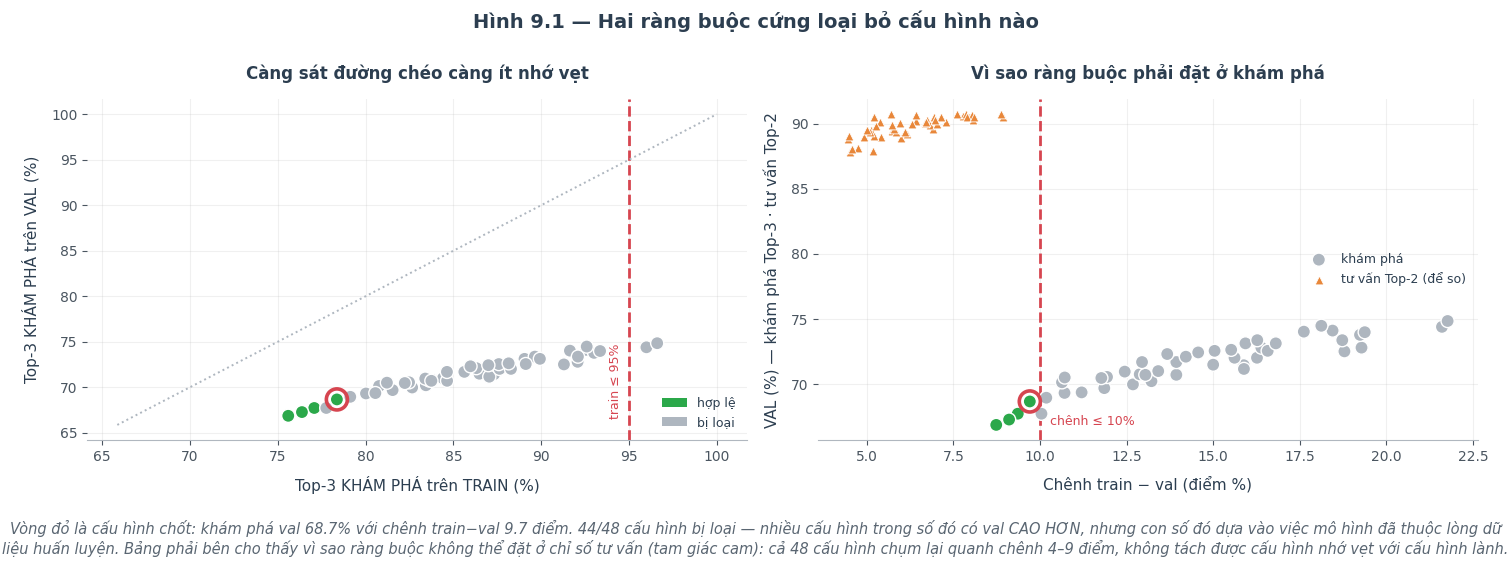

In [5]:
# ═══════════ HÌNH 9.1 — Đánh đổi giữa val và nhớ vẹt ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
mau = np.where(q.hop_le, C_GA, C_XAM)
a1.scatter(q.kp_train * 100, q.kp_val * 100, s=90, c=mau,
           edgecolor="white", lw=1, zorder=3)
a1.scatter([chot.kp_train * 100], [chot.kp_val * 100], s=230, facecolor="none",
           edgecolor=C_THAT, lw=2.6, zorder=4)
a1.axvline(KP_TRAIN_TOI_DA * 100, color=C_THAT, ls="--", lw=2)
a1.text(KP_TRAIN_TOI_DA * 100 - .4, q.kp_val.min() * 100,
        f"train ≤ {KP_TRAIN_TOI_DA:.0%}", fontsize=9, color=C_THAT,
        ha="right", rotation=90)
lo = min(q.kp_train.min(), q.kp_val.min()) * 100 - 1
a1.plot([lo, 100], [lo, 100], ":", color=C_XAM, lw=1.4)
a1.set_xlabel("Top-3 KHÁM PHÁ trên TRAIN (%)")
a1.set_ylabel("Top-3 KHÁM PHÁ trên VAL (%)")
a1.set_title("Càng sát đường chéo càng ít nhớ vẹt", fontsize=12)
a1.legend(handles=[Patch(facecolor=C_GA, label="hợp lệ"),
                   Patch(facecolor=C_XAM, label="bị loại")], fontsize=9, loc="lower right")

a2.scatter(q.gap_kp * 100, q.kp_val * 100, s=90, c=mau,
           edgecolor="white", lw=1, zorder=3, label="khám phá")
a2.scatter(q.gap_tv * 100, q.tv_val * 100, s=40, c=C_CAM, marker="^",
           edgecolor="white", lw=.6, zorder=2, label=f"tư vấn Top-{K_TU_VAN} (để so)")
a2.scatter([chot.gap_kp * 100], [chot.kp_val * 100], s=230, facecolor="none",
           edgecolor=C_THAT, lw=2.6, zorder=4)
a2.axvline(KP_GAP_TOI_DA * 100, color=C_THAT, ls="--", lw=2)
a2.text(KP_GAP_TOI_DA * 100 + .3, q.kp_val.min() * 100,
        f"chênh ≤ {KP_GAP_TOI_DA:.0%}", fontsize=9, color=C_THAT)
a2.set_xlabel("Chênh train − val (điểm %)")
a2.set_ylabel(f"VAL (%) — khám phá Top-3 · tư vấn Top-{K_TU_VAN}")
a2.set_title("Vì sao ràng buộc phải đặt ở khám phá", fontsize=12)
a2.legend(fontsize=9, loc="center right")

fig.suptitle("Hình 9.1 — Hai ràng buộc cứng loại bỏ cấu hình nào",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_9_1_rang_buoc.png",
    f"Vòng đỏ là cấu hình chốt: khám phá val {chot.kp_val:.1%} với chênh train−val "
    f"{chot.gap_kp*100:.1f} điểm. {int((~q.hop_le).sum())}/{len(q)} cấu hình bị loại — "
    f"nhiều cấu hình trong số đó có val CAO HƠN, nhưng con số đó dựa vào việc mô hình "
    f"đã thuộc lòng dữ liệu huấn luyện. Bảng phải bên cho thấy vì sao ràng buộc không "
    f"thể đặt ở chỉ số tư vấn (tam giác cam): cả 48 cấu hình chụm lại quanh chênh "
    f"{q.gap_tv.min()*100:.0f}–{q.gap_tv.max()*100:.0f} điểm, không tách được cấu hình "
    f"nhớ vẹt với cấu hình lành.")
plt.show()

   💾 hinh_9_2_vs_moc.png


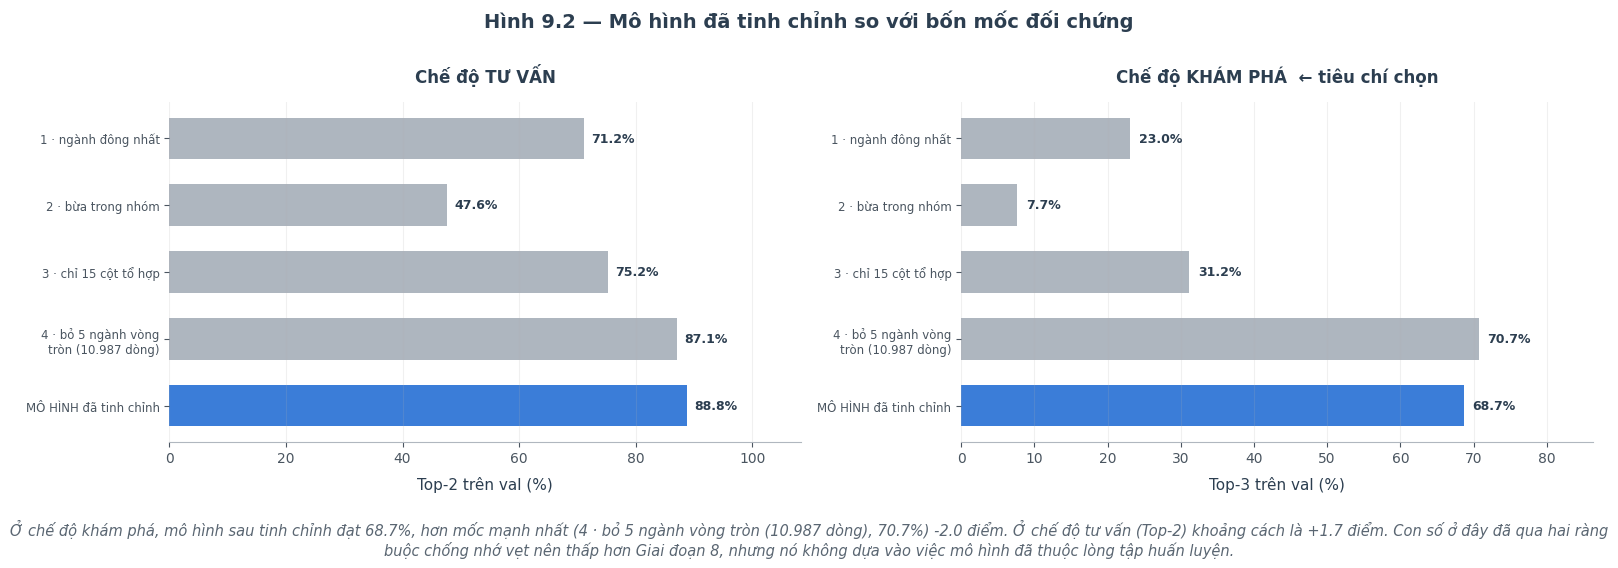

In [6]:
# ═══════════ HÌNH 9.2 — So với bốn mốc, cả hai chế độ ═══════════
ten_moc, gt_tv, gt_kp = [], [], []
for t, v in MOC["moc"].items():
    if not t.startswith("MÔ HÌNH"):
        ten_moc.append(t); gt_tv.append(v["tv_val"] * 100); gt_kp.append(v["kp_val"] * 100)
ten_moc.append("MÔ HÌNH đã tinh chỉnh")
gt_tv.append(chot.tv_val * 100); gt_kp.append(chot.kp_val * 100)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 5))
for ax, gt, ten_, k_ in [(a1, gt_tv, "Chế độ TƯ VẤN", K_TU_VAN),
                         (a2, gt_kp, "Chế độ KHÁM PHÁ  ← tiêu chí chọn", 3)]:
    mau2 = [C_XAM] * (len(ten_moc) - 1) + [C_XANH]
    ax.barh(np.arange(len(ten_moc)), gt, color=mau2, height=.62)
    ax.set_yticks(np.arange(len(ten_moc)))
    ax.set_yticklabels([ngat_dong(t, 22) for t in ten_moc], fontsize=8.5)
    ax.invert_yaxis(); ax.grid(axis="y", alpha=0)
    ax.set_xlabel(f"Top-{k_} trên val (%)"); ax.set_xlim(0, max(gt) * 1.22)
    ax.set_title(ten_, fontsize=12)
    for i, v_ in enumerate(gt):
        ax.text(v_ + 1.2, i, f"{v_:.1f}%", va="center", fontsize=9, fontweight="bold")

fig.suptitle("Hình 9.2 — Mô hình đã tinh chỉnh so với bốn mốc đối chứng",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
hon_tv = gt_tv[-1] - max(gt_tv[:-1])
hon = gt_kp[-1] - max(gt_kp[:-1])
luu(fig, OUT, "hinh_9_2_vs_moc.png",
    f"Ở chế độ khám phá, mô hình sau tinh chỉnh đạt {chot.kp_val:.1%}, hơn mốc mạnh "
    f"nhất ({ten_moc[int(np.argmax(gt_kp[:-1]))]}, {max(gt_kp[:-1]):.1f}%) {hon:+.1f} "
    f"điểm. Ở chế độ tư vấn (Top-{K_TU_VAN}) khoảng cách là {hon_tv:+.1f} điểm. "
    f"Con số ở đây đã qua hai ràng buộc chống nhớ vẹt nên thấp hơn Giai đoạn 8, nhưng "
    f"nó không dựa vào việc mô hình đã thuộc lòng tập huấn luyện.")
plt.show()

In [7]:
(OUT / "sieu_tham_so.json").write_text(json.dumps({
    "hp": hp_chot,
    "rieng_nhom": RIENG_NHOM,
    "rang_buoc": {"do_tren": "khám phá (xếp hạng cả 39 ngành)",
                  "kp_train_toi_da": KP_TRAIN_TOI_DA,
                  "kp_gap_toi_da": KP_GAP_TOI_DA},
    "n_cau_hinh": len(q), "n_hop_le": int(q.hop_le.sum()),
    "n_hop_le_neu_ap_len_tu_van": n_tv,
    "k_tu_van": K_TU_VAN,
    "val": {"kp_train": round(float(chot.kp_train), 4),
            "kp_val": round(float(chot.kp_val), 4),
            "gap_kp": round(float(chot.gap_kp), 4),
            "tv_train": round(float(chot.tv_train), 4),
            "tv_val": round(float(chot.tv_val), 4),
            "gap_tv": round(float(chot.gap_tv), 4)},
    "doi_chung_tang_tu_van": dc.to_dict("records"),
}, ensure_ascii=False, indent=2), encoding="utf-8")

tom_tat("GIAI ĐOẠN 9 — TINH CHỈNH", [
    f"Quét                   {len(q)} cấu hình",
    f"Ràng buộc cứng         đo trên chế độ KHÁM PHÁ",
    f"   khám phá train      ≤ {KP_TRAIN_TOI_DA:.0%}",
    f"   khám phá chênh      ≤ {KP_GAP_TOI_DA:.0%}",
    f"   hợp lệ              {int(q.hop_le.sum())}/{len(q)}",
    f"   (cùng ngưỡng áp lên tư vấn: {n_tv}/{len(q)} — nên không dùng được)",
    "",
    "CẤU HÌNH CHỐT:",
] + [f"   {k:<20} {hp_chot[k]}" for k in LUOI] + [
    f"   {'rieng_nhom':<20} {RIENG_NHOM}",
    "",
    f"Trên val (khám phá Top-3 · tư vấn Top-{K_TU_VAN}):",
    f"   {'':12}{'train':>9}{'val':>9}{'chênh':>9}",
    f"   {'khám phá':<12}{chot.kp_train:>9.1%}{chot.kp_val:>9.1%}"
    f"{chot.gap_kp*100:>+8.1f}đ",
    f"   {'tư vấn':<12}{chot.tv_train:>9.1%}{chot.tv_val:>9.1%}"
    f"{chot.gap_tv*100:>+8.1f}đ",
    "",
    f"Hơn mốc mạnh nhất      khám phá {hon:+.1f}đ · tư vấn {hon_tv:+.1f}đ",
    f"Giá của ràng buộc      −{hy_sinh*100:.1f} điểm khám phá val",
    "",
    "⚠️  Giai đoạn 10 mở test_KHOA.csv ĐÚNG MỘT LẦN bằng cấu hình này",
])
print(f"\n✅ sieu_tham_so.json · ket_qua_quet.csv · 2 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                          GIAI ĐOẠN 9 — TINH CHỈNH                          ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Quét                   48 cấu hình                                         ║
║ Ràng buộc cứng         đo trên chế độ KHÁM PHÁ                             ║
║    khám phá train      ≤ 95%                                               ║
║    khám phá chênh      ≤ 10%                                               ║
║    hợp lệ              4/48                                                ║
║    (cùng ngưỡng áp lên tư vấn: 13/48 — nên không dùng được)                ║
║                                                                            ║
║ CẤU HÌNH CHỐT:                                                             ║
║    n_estimators         150                                                ║
║    max_depth            3                         